# Diabetic Retinopathy Grading
Train EfficientNet-B5 on the preprocessed dataset with stratified splits and weighted sampling.


In [5]:
import os

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from sklearn.model_selection import train_test_split

from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.amp import GradScaler, autocast

import json
import csv
import time
import datetime

from sklearn.metrics import cohen_kappa_score, confusion_matrix
from tqdm.auto import tqdm

import matplotlib.pyplot as plt



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Load Labels & Filter to Existing Images

In [3]:
TRAIN_DIR = Path("dataset/train")
LABELS_CSV = Path("trainLabels.csv")
NUM_CLASSES = 5
IMG_SIZE = 456

df = pd.read_csv(LABELS_CSV)
# Build full file paths and keep only rows whose images actually exist
df["filepath"] = df["image"].apply(lambda x: str(TRAIN_DIR / f"{x}.jpeg"))
df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total images found: {len(df)}")
print(f"\nClass distribution:\n{df['level'].value_counts().sort_index()}")

Total images found: 35122

Class distribution:
level
0    25808
1     2442
2     5291
3      873
4      708
Name: count, dtype: int64


## 2. Stratified Train / Val / Test Split (70 / 10 / 20)

In [ ]:
# First split: 70% train, 30% temp (which becomes 20% test + 10% val)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["level"], random_state=42)

# Second split: split the 30% into 20% test and 10% val (2/3 and 1/3 of 30%)
test_df, val_df = train_test_split(temp_df, test_size=1/3, stratify=temp_df["level"], random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  Test: {len(test_df)}  Val: {len(val_df)}")
print(f"\nTrain class distribution:\n{train_df['level'].value_counts().sort_index()}")
print(f"\nTest class distribution:\n{test_df['level'].value_counts().sort_index()}")
print(f"\nVal class distribution:\n{val_df['level'].value_counts().sort_index()}")

Train: 24585  Test: 7024  Val: 3513

Train class distribution:
level
0    18065
1     1709
2     3704
3      611
4      496
Name: count, dtype: int64

Test class distribution:
level
0    5161
1     489
2    1058
3     175
4     141
Name: count, dtype: int64

Val class distribution:
level
0    2582
1     244
2     529
3      87
4      71
Name: count, dtype: int64


## 3. Class Weights for Loss-Based Balancing
Using cross entropy loss due to the class imbalance


In [5]:
class_counts = train_df["level"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # normalize to sum to 1
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Using loss-based balancing (weighted CrossEntropyLoss).")
print(f"Class counts: {dict(enumerate(class_counts))}")
print(f"Normalized class weights: {dict(enumerate(class_weights.round(6)))}")


Using loss-based balancing (weighted CrossEntropyLoss).
Class counts: {0: np.int64(18065), 1: np.int64(1709), 2: np.int64(3704), 3: np.int64(611), 4: np.int64(496)}
Normalized class weights: {0: np.float64(0.012131), 1: np.float64(0.128228), 2: np.float64(0.059163), 3: np.float64(0.35866), 4: np.float64(0.441818)}


## 4. Custom Dataset & Data Augmentations

In [6]:
class DRDatasetFromPaths(Dataset):
    """Dataset that loads images from disk."""

    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        label = int(self.labels[idx])
        if self.transform:
            image = self.transform(image)
        return image, label


### Tranforming the datasets

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]       #ImageNet normalization for pretrained EfficientNet
IMAGENET_STD = [0.229, 0.224, 0.225]       #ImageNet normalization for pretrained EfficientNet

train_transform = T.Compose([
    T.RandomRotation(degrees=360),          #Allowing images to be rotated 360 degrees
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# --- Build datasets -------------------------------------------------------
train_dataset = DRDatasetFromPaths(train_df["filepath"].tolist(), train_df["level"].tolist(), transform=train_transform)
test_dataset = DRDatasetFromPaths(test_df["filepath"].tolist(), test_df["level"].tolist(), transform=eval_transform)
val_dataset = DRDatasetFromPaths(val_df["filepath"].tolist(), val_df["level"].tolist(), transform=eval_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")


Train dataset size: 24585
Test  dataset size: 7024
Val   dataset size: 3513


## 5. DataLoaders

Load the datasets into each variable - train_loader, val_loader, test_loader for training and testing.

In [ ]:
BATCH_SIZE = 16
NUM_WORKERS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

## 6. Load EfficientNet-B5 from timm

In [ ]:
model = timm.create_model("efficientnet_b5", pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

print(model.default_cfg["input_size"])      #Expected input size of model
print(f"Classifier: {model.classifier}")    #Type of classifer model
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")  #Total parameters of model

(3, 448, 448)
Classifier: Linear(in_features=2048, out_features=5, bias=True)
Total parameters: 28,351,029


## 7. Training Configuration
Optimizer: AdamW. LR schedule: cosine annealing from `LR` to `1e-6` over all epochs. Mixed-precision scaler for AMP.

In [ ]:
NUM_EPOCHS = 10
LR = 3e-4                                   #Starting with default best practices for AdamW
WEIGHT_DECAY = 1e-4
# EARLY_STOP_PATIENCE = 2                     #Stop training if QWK doesn't improve for 2 consecutive epochs
BEST_CKPT_PATH = "models/best_efficientnet_b5.pt"

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler = GradScaler()

print(f"Optimizer : AdamW(lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Schedule : CosineAnnealingLR over {NUM_EPOCHS} epochs to eta_min=1e-6")
print(f"Batch : {BATCH_SIZE}")
print(f"Epochs : {NUM_EPOCHS}")

Optimizer : AdamW(lr=0.0003, weight_decay=0.0001)
Schedule  : CosineAnnealingLR over 10 epochs to eta_min=1e-6
Batch     : 16
Epochs    : 10


## 7.5 Run Logging Setup
Create a timestamped run directory and record every hyperparameter, optimizer/scheduler/loss config, per-epoch metric, final test result, confusion matrix, and timestamps to disk so runs can be compared later.

In [ ]:
#Timestamped run directory
RUN_TS = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = Path("logs") / f"run_{RUN_TS}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

Path("models").mkdir(parents=True, exist_ok=True)

#Each run gets a uniquely-named checkpoint
BEST_CKPT_PATH = str(Path("models") / f"best_efficientnet_b5_{RUN_TS}.pt")

config = {
    "run_ts": RUN_TS,
    "run_dir": str(RUN_DIR),
    "ckpt_path": BEST_CKPT_PATH,
    "seed": 42,

    "model_name": "efficientnet_b5",
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,

    "num_epochs": NUM_EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,

    "optimizer": {
        "name": "AdamW",
        "lr": LR,
        "weight_decay": WEIGHT_DECAY,
    },
    "scheduler": {
        "name": "CosineAnnealingLR",
        "T_max": NUM_EPOCHS,
        "eta_min": 1e-6,
    },
    "criterion": {
        "name": "CrossEntropyLoss (weighted)",
        "class_weights": class_weights.tolist(),
    },

    "train_size": len(train_dataset),
    "val_size": len(val_dataset),
    "test_size": len(test_dataset),

    "start_time": datetime.datetime.now().isoformat(timespec="seconds"),
}

with open(RUN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2, default=str)

#Per-epoch history CSV
HISTORY_CSV = RUN_DIR / "history.csv"
with open(HISTORY_CSV, "w", newline="") as f:
    csv.writer(f).writerow(
        ["epoch", "train_loss", "val_loss", "val_acc", "val_qwk", "lr", "epoch_time_s"]
    )

print(f"Logging to {RUN_DIR}")
print(f"Checkpoint -> {BEST_CKPT_PATH}")
print(f"Config written: {RUN_DIR/'config.json'}")

Logging to logs/run_20260411_233940
Checkpoint -> models/best_efficientnet_b5_20260411_233940.pt
Config written: logs/run_20260411_233940/config.json


## 8. Train / Eval Helpers
`train_one_epoch` runs one epoch with AMP, gradient accumulation, and gradient clipping.
`evaluate` runs a no-grad pass and returns loss, accuracy, **quadratic weighted kappa** (metric used in the competition), and the confusion matrix.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for input, target in tqdm(loader, desc="train", leave=False):
        input = input.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda"):        #https://docs.pytorch.org/docs/stable/amp.html Adding AMP to training
            logits = model(input)
            loss = criterion(logits, target)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * input.size(0)
        n_samples += input.size(0)

    return running_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_samples = 0
    all_preds, all_labels = [], []

    for input, target in tqdm(loader, desc="eval", leave=False):
        input = input.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        with autocast(device_type="cuda"):
            logits = model(input)
            loss = criterion(logits, target)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(target.cpu().numpy())

        running_loss += loss.item() * input.size(0)
        n_samples += input.size(0)

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    return {
        "loss": running_loss / n_samples,
        "acc":  (y_pred == y_true).mean(),
        "qwk":  cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "cm":   confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES))),
        "y_true": y_true,
        "y_pred": y_pred,
    }

## 9. Training Loop
Train, validate, step the LR scheduler, and save the best checkpoint by val QWK.
Stops early if val QWK does not improve for `EARLY_STOP_PATIENCE` epochs.

In [ ]:
best_qwk = -1.0
best_epoch = -1
# epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_qwk": [], "lr": [], "epoch_time_s": []}

train_start_ts = datetime.datetime.now()
train_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (lr={lr_now:.2e})")

    t0 = time.time()
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device,
    )
    val = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    epoch_time = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val["loss"])
    history["val_acc"].append(val["acc"])
    history["val_qwk"].append(val["qwk"])
    history["lr"].append(lr_now)
    history["epoch_time_s"].append(epoch_time)

    # Append per-epoch row to the run's history.csv
    with open(HISTORY_CSV, "a", newline="") as f:
        csv.writer(f).writerow([
            epoch,
            f"{train_loss:.6f}",
            f"{val['loss']:.6f}",
            f"{val['acc']:.6f}",
            f"{val['qwk']:.6f}",
            f"{lr_now:.8f}",
            f"{epoch_time:.2f}",
        ])

    print(
        f"train_loss={train_loss:.4f}  val_loss={val['loss']:.4f}  "
        f"val_acc={val['acc']:.4f}  val_qwk={val['qwk']:.4f}  "
        f"time={epoch_time:.1f}s"
    )

    if val["qwk"] > best_qwk:
        best_qwk = val["qwk"]
        best_epoch = epoch
        # epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT_PATH)
        print(f"[best] new best val QWK: {best_qwk:.4f} (saved {BEST_CKPT_PATH})")
    else:
        # epochs_no_improve += 1
        # print(f"no improvement ({epochs_no_improve}/{EARLY_STOP_PATIENCE})")
        # if epochs_no_improve >= EARLY_STOP_PATIENCE:
        #     print(f"Early stopping at epoch {epoch}. Best val QWK: {best_qwk:.4f}")
        #     break
        continue

train_end_ts = datetime.datetime.now()
duration_s = time.time() - train_start

summary = {
    "best_qwk": float(best_qwk),
    "best_epoch": int(best_epoch),
    "epochs_completed": len(history["train_loss"]),
    "start_time": train_start_ts.isoformat(timespec="seconds"),
    "end_time": train_end_ts.isoformat(timespec="seconds"),
    "duration_s": round(duration_s, 2),
    "duration_hms": str(datetime.timedelta(seconds=int(duration_s))),
    "ckpt_path": BEST_CKPT_PATH,
}
with open(RUN_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nTraining done. Best val QWK: {best_qwk:.4f} @ epoch {best_epoch}")
print(f"Duration: {summary['duration_hms']}  ({summary['duration_s']}s)")
print(f"Summary written: {RUN_DIR/'summary.json'}")


Epoch 1/10  (lr=3.00e-04)


  train_loss=1.5717  val_loss=1.2469  val_acc=0.2681  val_qwk=0.3397  time=499.0s
  [best] new best val QWK: 0.3397 (saved models/best_efficientnet_b5_20260411_233940.pt)

Epoch 2/10  (lr=2.93e-04)


  train_loss=1.3130  val_loss=1.1909  val_acc=0.1284  val_qwk=0.3445  time=495.1s
  [best] new best val QWK: 0.3445 (saved models/best_efficientnet_b5_20260411_233940.pt)

Epoch 3/10  (lr=2.71e-04)


  train_loss=1.2455  val_loss=1.1158  val_acc=0.6129  val_qwk=0.4747  time=495.1s
  [best] new best val QWK: 0.4747 (saved models/best_efficientnet_b5_20260411_233940.pt)

Epoch 4/10  (lr=2.38e-04)


  train_loss=1.2173  val_loss=1.0891  val_acc=0.6894  val_qwk=0.5277  time=494.9s
  [best] new best val QWK: 0.5277 (saved models/best_efficientnet_b5_20260411_233940.pt)

Epoch 5/10  (lr=1.97e-04)


...

  train_loss=1.1263  val_loss=1.0480  val_acc=0.7737  val_qwk=0.7139  time=495.4s
  [best] new best val QWK: 0.7139 (saved models/best_efficientnet_b5_20260411_233940.pt)

Epoch 7/10  (lr=1.04e-04)


  train_loss=1.0766  val_loss=1.0253  val_acc=0.5659  val_qwk=0.6239  time=495.4s

Epoch 8/10  (lr=6.26e-05)


  train_loss=1.0377  val_loss=0.9949  val_acc=0.7669  val_qwk=0.7327  time=495.7s
  [best] new best val QWK: 0.7327 (saved models/best_efficientnet_b5_20260411_233940.pt)

Epoch 9/10  (lr=2.96e-05)


  train_loss=0.9901  val_loss=0.9929  val_acc=0.7259  val_qwk=0.7276  time=496.5s

Epoch 10/10  (lr=8.32e-06)


  train_loss=0.9763  val_loss=0.9637  val_acc=0.7720  val_qwk=0.7418  time=496.6s
  [best] new best val QWK: 0.7418 (saved models/best_efficientnet_b5_20260411_233940.pt)

Training done. Best val QWK: 0.7418 @ epoch 10
Duration: 1:23:00  (4980.03s)
Summary written: logs/run_20260411_233940/summary.json


## 10. Final Test Evaluation
Load the best checkpoint (by val QWK) and run it once on the held-out test set. Report QWK, accuracy, and the confusion matrix.

In [ ]:
model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=device))

eval_start = time.time()
test = evaluate(model, test_loader, criterion, device)
eval_time = time.time() - eval_start

print(f"Test loss : {test['loss']:.4f}")
print(f"Test acc : {test['acc']:.4f}")
print(f"Test QWK : {test['qwk']:.4f}")

print("\nConfusion matrix (rows=true, cols=pred):")
cm_df = pd.DataFrame(
    test["cm"],
    index=[f"true_{i}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{i}" for i in range(NUM_CLASSES)],
)
print(cm_df)

#Save final test results to the run directory
test_results = {
    "loss": float(test["loss"]),
    "acc": float(test["acc"]),
    "qwk": float(test["qwk"]),
    "ckpt_path": BEST_CKPT_PATH,
    "eval_time_s": round(eval_time, 2),
    "evaluated_at": datetime.datetime.now().isoformat(timespec="seconds"),
}
with open(RUN_DIR / "test_results.json", "w") as f:
    json.dump(test_results, f, indent=2)

np.savetxt(RUN_DIR / "confusion_matrix.csv", test["cm"], fmt="%d", delimiter=",")
np.savez(RUN_DIR / "predictions.npz", y_true=test["y_true"], y_pred=test["y_pred"])

print(f"\nTest results written: {RUN_DIR/'test_results.json'}")
print(f"Confusion matrix : {RUN_DIR/'confusion_matrix.csv'}")
print(f"Predictions : {RUN_DIR/'predictions.npz'}")

Test loss : 1.0677
Test acc  : 0.7584
Test QWK  : 0.7179

Confusion matrix (rows=true, cols=pred):
        pred_0  pred_1  pred_2  pred_3  pred_4
true_0    4440     466     232       0      23
true_1     283     135      69       1       1
true_2     202     154     589      93      20
true_3      11       5      57      88      14
true_4       6       1      32      27      75

Test results written: logs/run_20260411_233940/test_results.json
Confusion matrix   : logs/run_20260411_233940/confusion_matrix.csv
Predictions        : logs/run_20260411_233940/predictions.npz


## 11. Visualization — Training Curves & Confusion Matrix
Plots metrics from the saved run directory. Defaults to the current run but can use prior `logs/run_YYYYMMDD_HHMMSS/` to compare experiments.

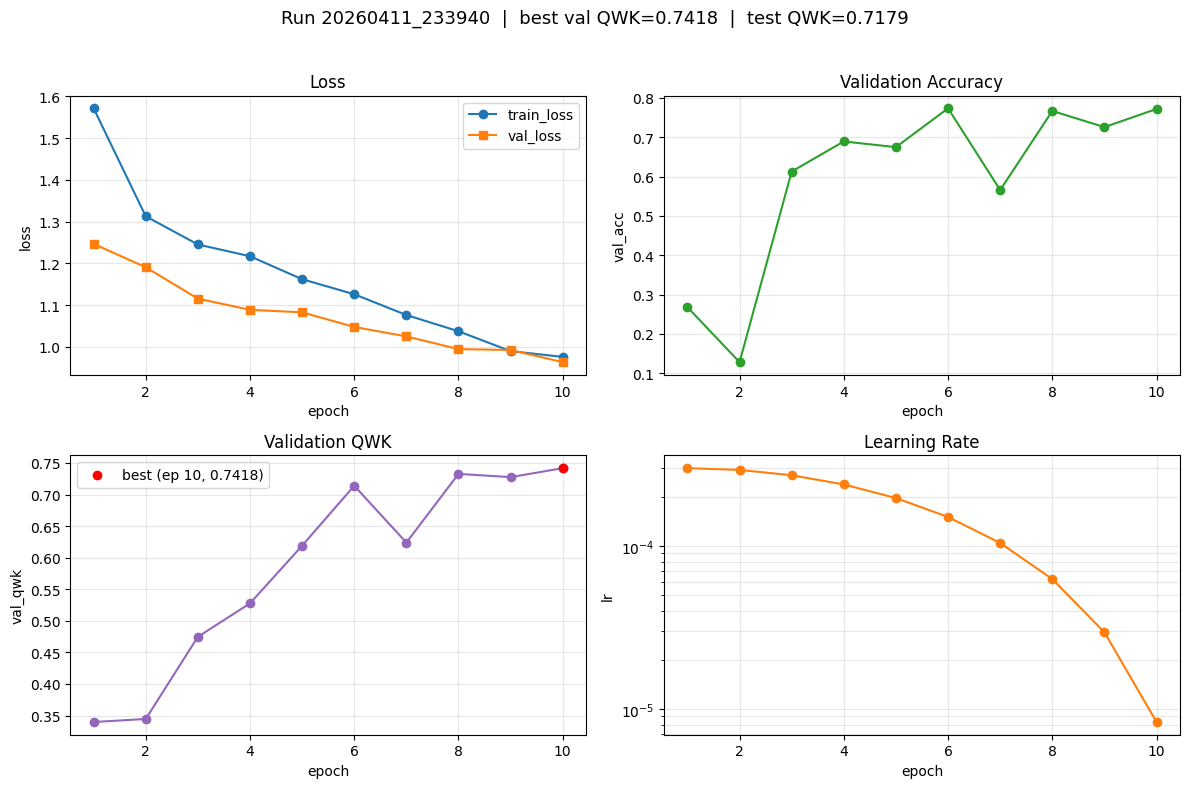

Saved logs/run_20260411_233940/curves.png


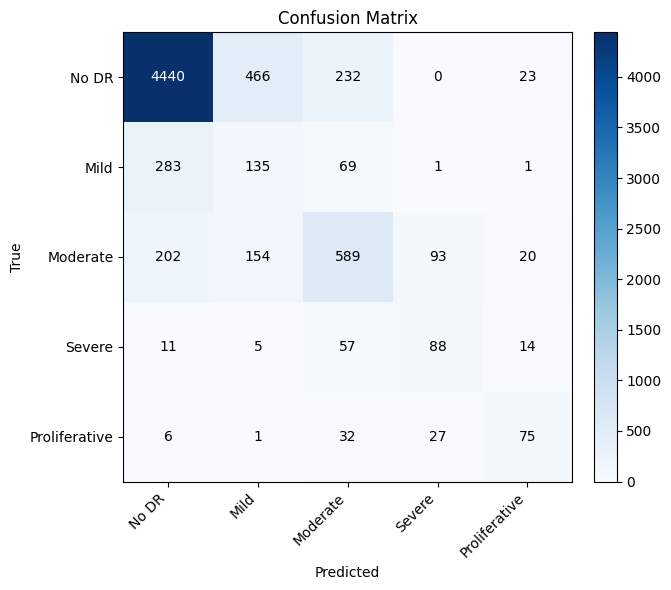

Saved logs/run_20260411_233940/confusion_matrix.png


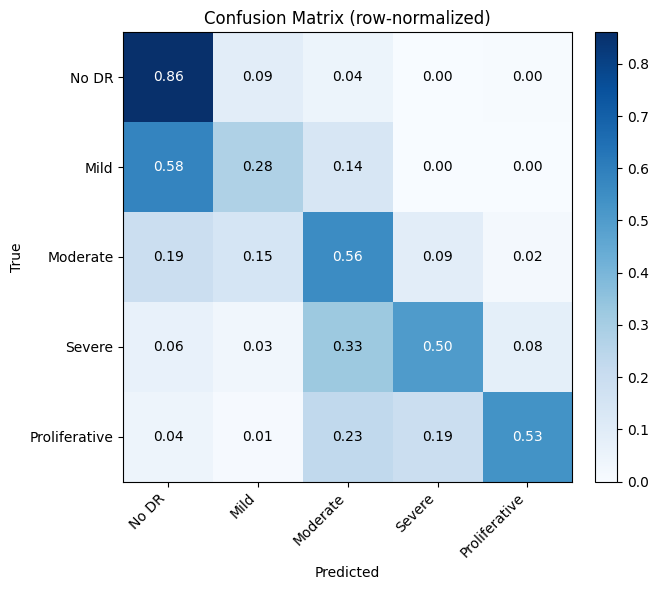

Saved logs/run_20260411_233940/confusion_matrix_norm.png


In [ ]:
def load_run(run_dir):
    run_dir = Path(run_dir)
    hist = pd.read_csv(run_dir / "history.csv")
    with open(run_dir / "config.json") as f:
        cfg = json.load(f)
    summary = None
    if (run_dir / "summary.json").exists():
        with open(run_dir / "summary.json") as f:
            summary = json.load(f)
    test_res = None
    if (run_dir / "test_results.json").exists():
        with open(run_dir / "test_results.json") as f:
            test_res = json.load(f)
    return run_dir, hist, cfg, summary, test_res


def plot_run(run_dir=None):
    """Plot training curves for a run (defaults to the current RUN_DIR)."""
    if run_dir is None:
        run_dir = RUN_DIR
    run_dir, hist, cfg, summary, test_res = load_run(run_dir)

    best_epoch = summary["best_epoch"] if summary else None
    best_qwk = summary["best_qwk"] if summary else None

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    #(0,0) Loss curves
    ax = axes[0, 0]
    ax.plot(hist["epoch"], hist["train_loss"], marker="o", label="train_loss")
    ax.plot(hist["epoch"], hist["val_loss"], marker="s", label="val_loss")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.set_title("Loss")
    ax.grid(alpha=0.3); ax.legend()

    #(0,1) Val accuracy
    ax = axes[0, 1]
    ax.plot(hist["epoch"], hist["val_acc"], marker="o", color="tab:green")
    ax.set_xlabel("epoch"); ax.set_ylabel("val_acc")
    ax.set_title("Validation Accuracy")
    ax.grid(alpha=0.3)

    #(1,0) Val QWK with best-epoch marker
    ax = axes[1, 0]
    ax.plot(hist["epoch"], hist["val_qwk"], marker="o", color="tab:purple")
    if best_epoch is not None and best_qwk is not None:
        ax.scatter([best_epoch], [best_qwk], color="red", zorder=5,
                   label=f"best (ep {best_epoch}, {best_qwk:.4f})")
        ax.legend()
    ax.set_xlabel("epoch"); ax.set_ylabel("val_qwk")
    ax.set_title("Validation QWK")
    ax.grid(alpha=0.3)

    #(1,1) LR schedule
    ax = axes[1, 1]
    ax.plot(hist["epoch"], hist["lr"], marker="o", color="tab:orange")
    ax.set_xlabel("epoch"); ax.set_ylabel("lr")
    ax.set_title("Learning Rate")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")

    #Title with run metadata
    title_bits = [f"Run {cfg.get('run_ts', run_dir.name)}"]
    if best_qwk is not None:
        title_bits.append(f"best val QWK={best_qwk:.4f}")
    if test_res is not None:
        title_bits.append(f"test QWK={test_res['qwk']:.4f}")
    fig.suptitle("  |  ".join(title_bits), fontsize=13)

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    out = run_dir / "curves.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")


def plot_confusion_matrix(run_dir=None, normalize=False):
    """Render the confusion matrix saved in run_dir as a heatmap."""
    if run_dir is None:
        run_dir = RUN_DIR
    run_dir = Path(run_dir)
    cm = np.loadtxt(run_dir / "confusion_matrix.csv", delimiter=",", dtype=int)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        display_cm = np.divide(cm.astype(float), row_sums, where=row_sums != 0, out=None)
        fmt = ".2f"
    else:
        display_cm = cm
        fmt = "d"

    labels = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(display_cm, cmap="Blues")
    ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    title = "Confusion Matrix (row-normalized)" if normalize else "Confusion Matrix"
    ax.set_title(title)

    #Annotate each cell
    thresh = display_cm.max() / 2.0 if display_cm.max() > 0 else 0.5
    for i in range(display_cm.shape[0]):
        for j in range(display_cm.shape[1]):
            val = display_cm[i, j]
            text = format(val, fmt)
            color = "white" if val > thresh else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    out = run_dir / ("confusion_matrix_norm.png" if normalize else "confusion_matrix.png")
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")


plot_run()
plot_confusion_matrix()
plot_confusion_matrix(normalize=True)

# plot_run("logs/run_20260411_233940")
# plot_confusion_matrix("logs/run_20260411_233940")
# plot_confusion_matrix("logs/run_20260411_233940", normalize=True)

In [ ]:
torch.amp.autocast_mode.is_autocast_available(str(device))